## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Set style for better visualizations


In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Descriptive Statistics

### Load and prepare data

In [4]:
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Display basic info about the dataset
print("FNSPID DATASET OVERVIEW")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

# Convert date column - this format works with the timezone offset
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)

FNSPID DATASET OVERVIEW
Dataset shape: (1407328, 6)

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

Data types:
Unnamed: 0     int64
headline      object
url           object
publisher     object
date          object
stock         object
dtype: object

First 5 rows:
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin 

### Headline Character Count Distribution

HEADLINE TEXTUAL LENGTHS ANALYSIS

📊 Headline Character Length Statistics:
   Mean length: 73.1 characters
   Median length: 64.0 characters
   Min length: 3 characters
   Max length: 512 characters
   Std deviation: 40.7 characters

📊 Word Count Statistics:
   Mean words: 11.4
   Median words: 10.0
   Min words: 1
   Max words: 77

📊 Character Length Percentiles:
   1th percentile: 22 characters
   5th percentile: 30 characters
   10th percentile: 36 characters
   25th percentile: 47 characters
   50th percentile: 64 characters
   75th percentile: 87 characters
   90th percentile: 117 characters
   95th percentile: 153 characters
   99th percentile: 235 characters


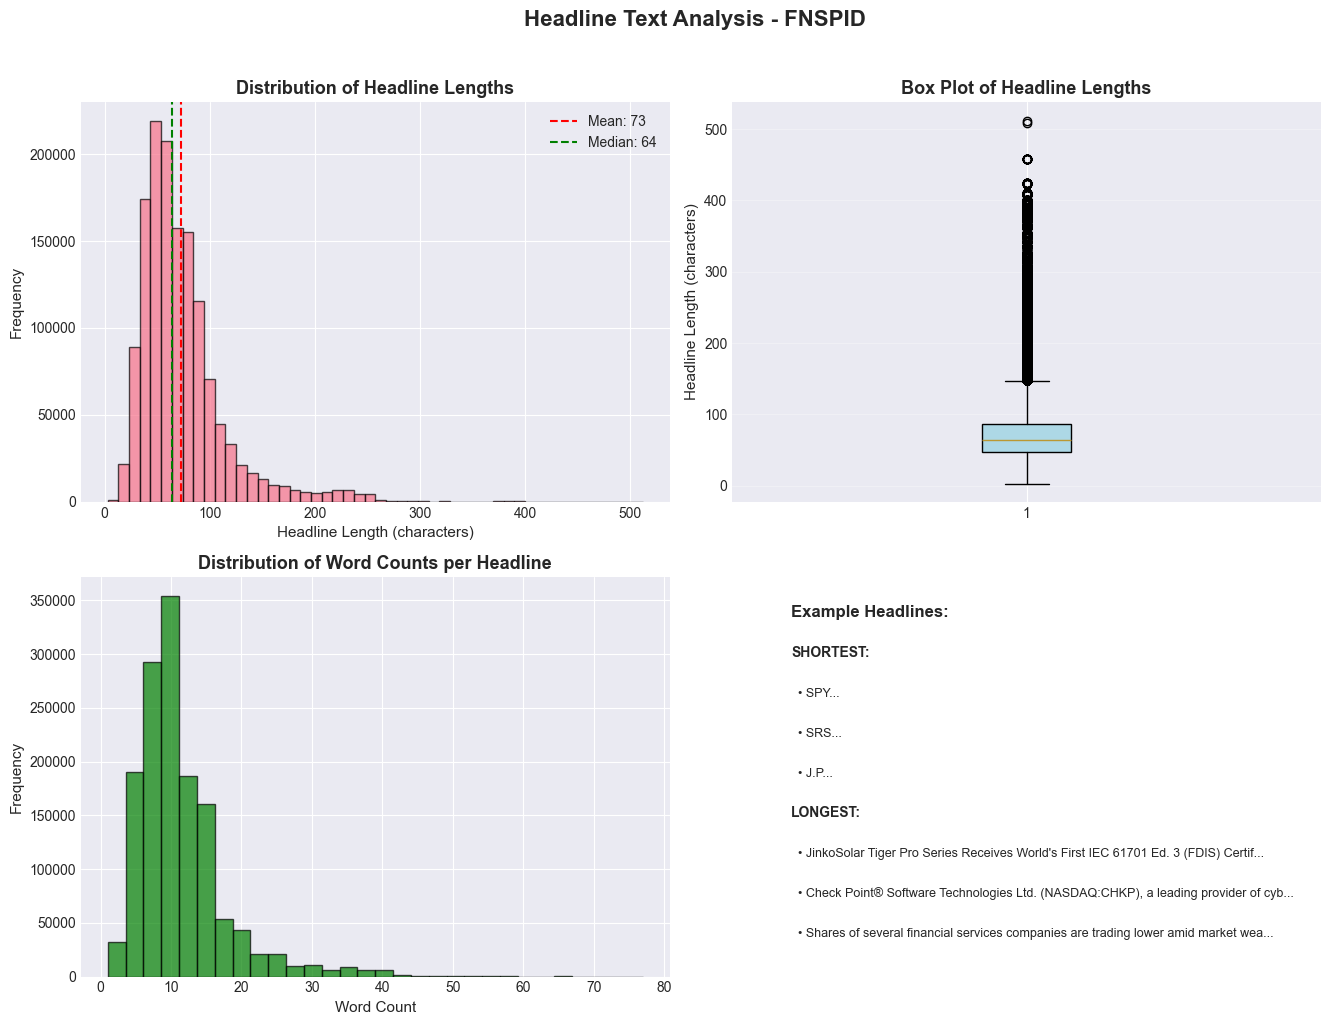

In [ ]:
print("HEADLINE TEXTUAL LENGTHS ANALYSIS")

# Calculate headline lengths
headline_col = 'headline' if 'headline' in df.columns else df.columns[0]
df['headline_length'] = df[headline_col].astype(str).str.len()
df['word_count'] = df[headline_col].astype(str).str.split().str.len()

# Basic statistics
print(f"\n📊 Headline Character Length Statistics:")
print(f"   Mean length: {df['headline_length'].mean():.1f} characters")
print(f"   Median length: {df['headline_length'].median():.1f} characters")
print(f"   Min length: {df['headline_length'].min()} characters")
print(f"   Max length: {df['headline_length'].max()} characters")
print(f"   Std deviation: {df['headline_length'].std():.1f} characters")

print(f"\n📊 Word Count Statistics:")
print(f"   Mean words: {df['word_count'].mean():.1f}")
print(f"   Median words: {df['word_count'].median():.1f}")
print(f"   Min words: {df['word_count'].min()}")
print(f"   Max words: {df['word_count'].max()}")

# Length distribution percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print(f"\n📊 Character Length Percentiles:")
for p in percentiles:
    value = df['headline_length'].quantile(p/100)
    print(f"   {p}th percentile: {value:.0f} characters")

# Visualizations for headline lengths
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of character lengths
axes[0, 0].hist(df['headline_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Headline Length (characters)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Headline Lengths', fontsize=13, fontweight='bold')
axes[0, 0].axvline(df['headline_length'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df['headline_length'].mean():.0f}")
axes[0, 0].axvline(df['headline_length'].median(), color='green', linestyle='--', 
                   label=f"Median: {df['headline_length'].median():.0f}")
axes[0, 0].legend()

# Box plot of character lengths
box = axes[0, 1].boxplot(df['headline_length'], vert=True, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_ylabel('Headline Length (characters)', fontsize=11)
axes[0, 1].set_title('Box Plot of Headline Lengths', fontsize=13, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# Histogram of word counts
axes[1, 0].hist(df['word_count'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Word Count', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Word Counts per Headline', fontsize=13, fontweight='bold')

# Example headlines of different lengths
short_headlines = df.nsmallest(3, 'headline_length')[headline_col].tolist()
long_headlines = df.nlargest(3, 'headline_length')[headline_col].tolist()

axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.9, "Example Headlines:", fontsize=12, fontweight='bold')
axes[1, 1].text(0.1, 0.8, "SHORTEST:", fontsize=10, fontweight='bold')
for i, headline in enumerate(short_headlines):
    axes[1, 1].text(0.1, 0.7 - i*0.1, f"  • {headline[:50]}...", fontsize=9, wrap=True)
axes[1, 1].text(0.1, 0.4, "LONGEST:", fontsize=10, fontweight='bold')
for i, headline in enumerate(long_headlines):
    axes[1, 1].text(0.1, 0.3 - i*0.1, f"  • {headline[:80]}...", fontsize=9, wrap=True)

plt.suptitle('Headline Text Analysis - FNSPID', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Articles per publisher analysis

PUBLISHER ACTIVITY ANALYSIS

📊 Total unique publishers: 1034

📊 Top 10 Most Active Publishers:
--------------------------------------------------
    1. Paul Quintaro                            228,373 articles (16.2%)
    2. Lisa Levin                               186,979 articles (13.3%)
    3. Benzinga Newsdesk                        150,484 articles (10.7%)
    4. Charles Gross                            96,732 articles (6.9%)
    5. Monica Gerson                            82,380 articles (5.9%)
    6. Eddie Staley                             57,254 articles (4.1%)
    7. Hal Lindon                               49,047 articles (3.5%)
    8. ETF Professor                            28,489 articles (2.0%)
    9. Juan Lopez                               28,438 articles (2.0%)
   10. Benzinga Staff                           28,114 articles (2.0%)


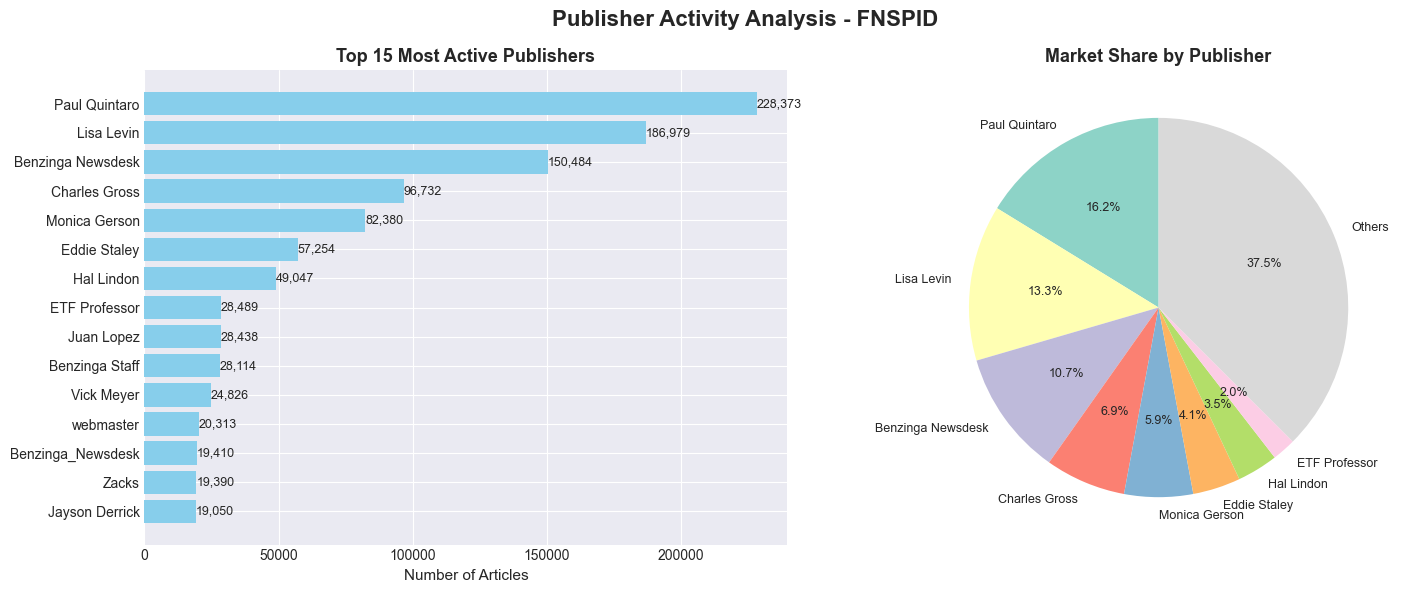


📊 Publisher Concentration Analysis:
   Herfindahl-Hirschman Index (HHI): 0.0700
   → Moderately concentrated


In [ ]:
print("PUBLISHER ACTIVITY ANALYSIS")

publisher_col = 'publisher'
publisher_counts = df[publisher_col].value_counts()

print(f"\n📊 Total unique publishers: {len(publisher_counts)}")
print(f"\n📊 Top 10 Most Active Publishers:")
print("-" * 50)
for i, (publisher, count) in enumerate(publisher_counts.head(10).items(), 1):
    percentage = (count / len(df)) * 100
    print(f"   {i:2d}. {str(publisher)[:40]:<40} {count:>6,} articles ({percentage:.1f}%)")

# Handle email addresses as publisher names (extract domains)
df['publisher_domain'] = df[publisher_col].astype(str).str.split('@').str[-1]

# Check if most publishers look like email addresses
email_pattern = r'.*@.*\..*'
email_publishers = df[publisher_col].astype(str).str.contains(email_pattern, na=False).sum()

if email_publishers > len(df) * 0.5:
    print(f"\n📧 Detected {email_publishers:,} email-based publishers ({email_publishers/len(df)*100:.1f}%)")
    print("\n📊 Top 10 Publisher Domains:")
    domain_counts = df['publisher_domain'].value_counts()
    for i, (domain, count) in enumerate(domain_counts.head(10).items(), 1):
        if '@' not in domain and '.' in domain:  # Valid domain
            percentage = (count / len(df)) * 100
            print(f"   {i:2d}. {domain:<40} {count:>6,} articles ({percentage:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 publishers bar chart
top_publishers = publisher_counts.head(15)
bars = axes[0].barh(range(len(top_publishers)), top_publishers.values, color='skyblue')
axes[0].set_yticks(range(len(top_publishers)))
axes[0].set_yticklabels([str(p)[:30] for p in top_publishers.index])
axes[0].set_xlabel('Number of Articles', fontsize=11)
axes[0].set_title('Top 15 Most Active Publishers', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_publishers.values)):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2, 
                f'{val:,}', va='center', fontsize=9)

# Market share pie chart (top 8, rest as "Others")
top_8 = publisher_counts.head(8)
others_count = publisher_counts[8:].sum()

if others_count > 0:
    pie_data = pd.concat([top_8, pd.Series({'Others': others_count})])
else:
    pie_data = top_8

colors = plt.cm.Set3(range(len(pie_data)))
axes[1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Market Share by Publisher', fontsize=13, fontweight='bold')

plt.suptitle('Publisher Activity Analysis - FNSPID', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Concentration analysis (Herfindahl Index)
market_shares = publisher_counts / len(df)
hhi = (market_shares ** 2).sum()
print(f"\n📊 Publisher Concentration Analysis:")
print(f"   Herfindahl-Hirschman Index (HHI): {hhi:.4f}")
if hhi < 0.01:
    print("   → Highly competitive (many diverse publishers)")
elif hhi < 0.15:
    print("   → Moderately concentrated")
else:
    print("   → Highly concentrated (few dominant publishers)")

### Publication date trends

PUBLICATION DATE TRENDS ANALYSIS

📊 Time Range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
   Total trading days with news: 3955
   Average articles per day: 355.8
   Median articles per day: 407.0
   Max articles in a single day: 2,739

📊 News Volume Analysis:
   Spike detection threshold (mean + 2σ): 918.9 articles
   Number of spike days: 85

📈 Top 10 Days with Highest News Volume (Potential Market Events):
    1. 2020-03-12 00:00:00: 2,739 articles
    2. 2020-02-28 00:00:00: 1,620 articles
    3. 2020-03-19 00:00:00: 1,595 articles
    4. 2020-02-27 00:00:00: 1,567 articles
    5. 2020-03-06 00:00:00: 1,428 articles
    6. 2020-05-07 00:00:00: 1,398 articles
    7. 2020-03-23 00:00:00: 1,391 articles
    8. 2020-04-29 00:00:00: 1,389 articles
    9. 2020-03-11 00:00:00: 1,384 articles
   10. 2020-04-30 00:00:00: 1,327 articles

📊 Publication Volume by Day of Week:
   Monday    : 265,139 articles ██████████████████████████
   Tuesday   : 296,505 articles ███████████████

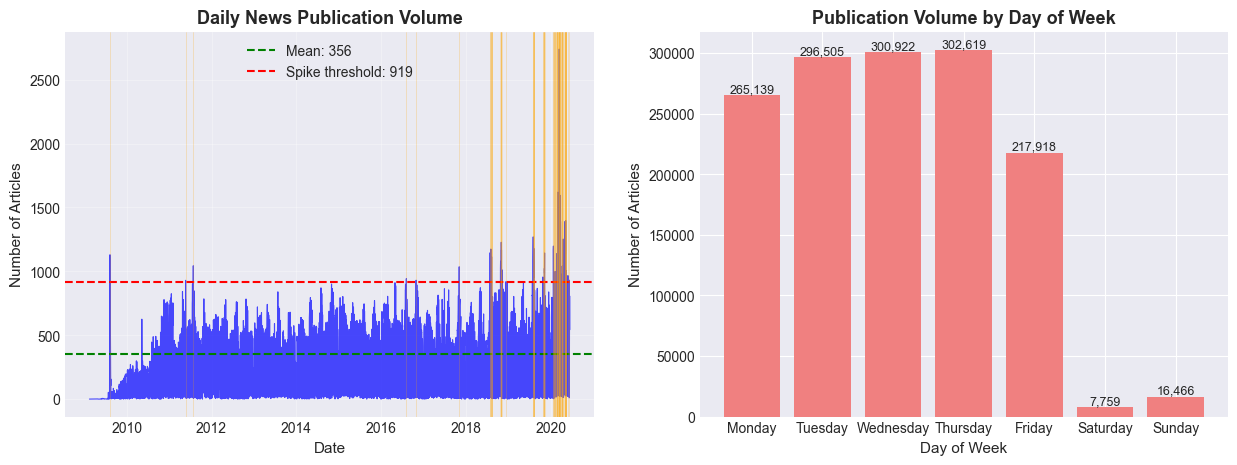

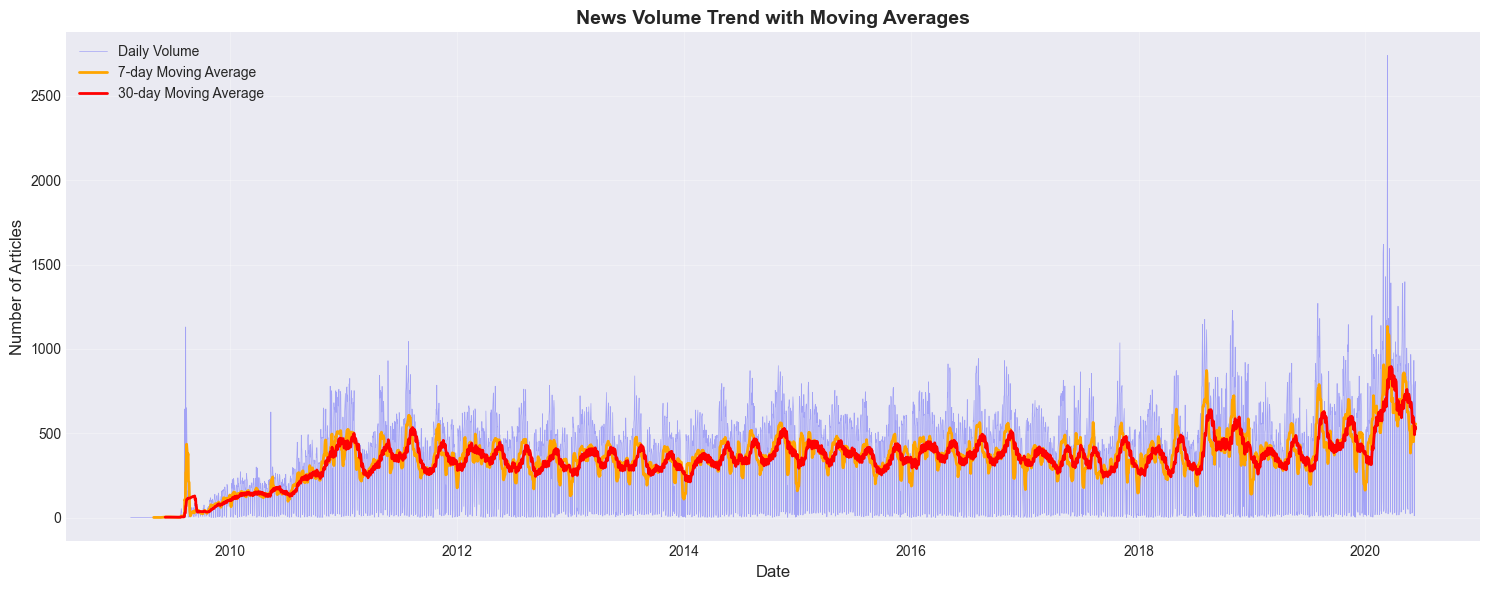

In [ ]:
print("PUBLICATION DATE TRENDS ANALYSIS")

date_column = 'date'
# Extract temporal features
df['year'] = df[date_column].dt.year
df['month'] = df[date_column].dt.month
df['day'] = df[date_column].dt.day
df['dayofweek'] = df[date_column].dt.dayofweek
df['hour'] = df[date_column].dt.hour
df['date_only'] = df[date_column].dt.date

# Daily publication volume
daily_volume = df.groupby('date_only').size()
daily_volume.index = pd.to_datetime(daily_volume.index)

print(f"\n📊 Time Range: {df[date_column].min()} to {df[date_column].max()}")
print(f"   Total trading days with news: {len(daily_volume)}")
print(f"   Average articles per day: {daily_volume.mean():.1f}")
print(f"   Median articles per day: {daily_volume.median():.1f}")
print(f"   Max articles in a single day: {daily_volume.max():,}")

# Identify high-volume days (potential market events)
threshold = daily_volume.mean() + 2 * daily_volume.std()
spike_days = daily_volume[daily_volume > threshold]

print(f"\n📊 News Volume Analysis:")
print(f"   Spike detection threshold (mean + 2σ): {threshold:.1f} articles")
print(f"   Number of spike days: {len(spike_days)}")

if len(spike_days) > 0:
    print(f"\n📈 Top 10 Days with Highest News Volume (Potential Market Events):")
    for i, (date, volume) in enumerate(spike_days.nlargest(10).items(), 1):
        print(f"   {i:2d}. {date}: {volume:,} articles")

# Day of week patterns
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_volume = df.groupby('dayofweek').size()

print(f"\n📊 Publication Volume by Day of Week:")
for i, (dow, vol) in enumerate(dow_volume.items()):
    bar = '█' * int(vol / dow_volume.max() * 30)
    print(f"   {dow_names[dow]:10s}: {vol:6,} articles {bar}")

# Hourly patterns (if time information available)
if df['hour'].nunique() > 1:
    print(f"\n📊 Publication Volume by Hour of Day (UTC-4):")
    hour_volume = df.groupby('hour').size()
    peak_hour = hour_volume.idxmax()
    print(f"   Peak publishing hour: {peak_hour}:00 ({hour_volume[peak_hour]:,} articles)")
    
    # Pre-market vs market hours analysis
    pre_market = hour_volume[hour_volume.index < 9.5].sum() if 9.5 in hour_volume.index else 0
    market_hours = hour_volume[(hour_volume.index >= 9.5) & (hour_volume.index < 16)].sum()
    after_hours = hour_volume[hour_volume.index >= 16].sum()
    
    print(f"\n   Pre-market (before 9:30): {pre_market:,} articles")
    print(f"   Market hours (9:30-16:00): {market_hours:,} articles")
    print(f"   After-hours (after 16:00): {after_hours:,} articles")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Time series of daily publication volume
axes[0].plot(daily_volume.index, daily_volume.values, 'b-', alpha=0.7, linewidth=0.8)
axes[0].axhline(y=daily_volume.mean(), color='g', linestyle='--', 
                    label=f"Mean: {daily_volume.mean():.0f}")
axes[0].axhline(y=threshold, color='r', linestyle='--', 
                    label=f"Spike threshold: {threshold:.0f}")
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Number of Articles', fontsize=11)
axes[0].set_title('Daily News Publication Volume', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Highlight spike days
for date in spike_days.index:
    axes[0].axvline(x=date, color='orange', alpha=0.3, linewidth=0.5)

# Day of week bar chart
bars = axes[1].bar(range(7), dow_volume, color='lightcoral')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].set_xlabel('Day of Week', fontsize=11)
axes[1].set_ylabel('Number of Articles', fontsize=11)
axes[1].set_title('Publication Volume by Day of Week', fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, dow_volume):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f'{val:,}', ha='center', va='bottom', fontsize=9)

# Monthly volume (if multiple years)
monthly_volume = df.groupby(['year', 'month']).size()

# Rolling average to identify trends
fig, ax = plt.subplots(figsize=(15, 6))
rolling_7d = daily_volume.rolling(window=7, min_periods=3).mean()
rolling_30d = daily_volume.rolling(window=30, min_periods=10).mean()

ax.plot(daily_volume.index, daily_volume.values, 'b-', alpha=0.3, linewidth=0.5, label='Daily Volume')
ax.plot(rolling_7d.index, rolling_7d.values, 'orange', linewidth=2, label='7-day Moving Average')
ax.plot(rolling_30d.index, rolling_30d.values, 'red', linewidth=2, label='30-day Moving Average')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('News Volume Trend with Moving Averages', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Text Analysis (Topic Modeling)

### Text preprocessing

In [8]:
print("TEXT PREPROCESSING")

def preprocess_text(text):
    """Clean and preprocess headline text"""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and digits (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove stop words
    words = text.split()
    words = [w for w in words if w not in STOP_WORDS]
    text = ' '.join(words)
    
    return text

# List of common English stop words to remove
STOP_WORDS = set([
    'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'has', 'he',
    'in', 'is', 'it', 'its', 'of', 'on', 'that', 'the', 'to', 'was', 'were',
    'will', 'with', 'this', 'that', 'these', 'those', 'but', 'or', 'so', 'for',
    'not', 'can', 'could', 'would', 'should', 'up', 'down', 'out', 'over', 'under',
    'again', 'further', 'then', 'once', 'here', 'there', 'all', 'any', 'both',
    'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'only',
    'own', 'same', 'than', 'then', 'too', 'very', 'just', 'but', 'do', 'does',
    'doing', 'did', 'am', 'have', 'having', 'being', 'been', 'on', 'vs', 'est', 
    'benzingas', 'week', 'top', 'pt', 'set', 'new', 'several','yesterday', 
    'session', 'hit', 'which', 'scheduled', 'moving', 'companies',
    'stocks', 'shares', 'market'  # These are too generic to be meaningful
])

# Apply preprocessing
df['clean_headline'] = df['headline'].apply(preprocess_text)

print(f"✅ Processed {len(df)} headlines")
print(f"\nSample before cleaning: {df['headline'].iloc[0]}")
print(f"Sample after cleaning: {df['clean_headline'].iloc[0]}")

TEXT PREPROCESSING
✅ Processed 1407328 headlines

Sample before cleaning: Stocks That Hit 52-Week Highs On Friday
Sample after cleaning: highs friday


### Most common keywords and phrases

In [ ]:
print("COMMON KEYWORDS AND PHRASES")

# 2a. Single words (unigrams)
vectorizer_unigram = CountVectorizer(
    stop_words=list(STOP_WORDS),
    max_features=30,
    ngram_range=(1, 1)
)

unigram_counts = vectorizer_unigram.fit_transform(df['clean_headline'])
unigram_sum = unigram_counts.toarray().sum(axis=0)
unigram_words = vectorizer_unigram.get_feature_names_out()

unigram_freq = sorted(zip(unigram_words, unigram_sum), key=lambda x: x[1], reverse=True)

print("\n📊 TOP 20 MOST COMMON INDIVIDUAL WORDS:")
print("-" * 40)
for i, (word, count) in enumerate(unigram_freq[:20], 1):
    print(f"   {i:2d}. {word:<20} {count:>6,} occurrences")

# 2b. Two-word phrases (bigrams)
vectorizer_bigram = CountVectorizer(
    stop_words=list(STOP_WORDS),
    max_features=30,
    ngram_range=(2, 2)
)

bigram_counts = vectorizer_bigram.fit_transform(df['clean_headline'])
bigram_sum = bigram_counts.toarray().sum(axis=0)
bigram_phrases = vectorizer_bigram.get_feature_names_out()

bigram_freq = sorted(zip(bigram_phrases, bigram_sum), key=lambda x: x[1], reverse=True)

print("\n\n📊 TOP 20 MOST COMMON TWO-WORD PHRASES:")
print("-" * 50)
for i, (phrase, count) in enumerate(bigram_freq[:20], 1):
    print(f"   {i:2d}. {phrase:<30} {count:>6,} occurrences")

# 2c. Three-word phrases (trigrams)
vectorizer_trigram = CountVectorizer(
    stop_words=list(STOP_WORDS),
    max_features=20,
    ngram_range=(3, 3)
)

trigram_counts = vectorizer_trigram.fit_transform(df['clean_headline'])
trigram_sum = trigram_counts.toarray().sum(axis=0)
trigram_phrases = vectorizer_trigram.get_feature_names_out()

trigram_freq = sorted(zip(trigram_phrases, trigram_sum), key=lambda x: x[1], reverse=True)

print("\n\n📊 TOP 15 MOST COMMON THREE-WORD PHRASES:")
print("-" * 55)
for i, (phrase, count) in enumerate(trigram_freq[:15], 1):
    print(f"   {i:2d}. {phrase:<35} {count:>6,} occurrences")      

COMMON KEYWORDS AND PHRASES

📊 TOP 20 MOST COMMON INDIVIDUAL WORDS:
----------------------------------------
    1. eps                  128,929 occurrences
    2. reports              108,707 occurrences
    3. update               91,680 occurrences
    4. earnings             87,185 occurrences
    5. sales                79,526 occurrences
    6. announces            66,529 occurrences
    7. price                64,232 occurrences
    8. buy                  64,060 occurrences
    9. downgrades           61,942 occurrences
   10. trading              61,158 occurrences
   11. raises               57,798 occurrences
   12. upgrades             56,804 occurrences
   13. target               54,620 occurrences
   14. maintains            52,961 occurrences
   15. us                   49,159 occurrences
   16. higher               48,163 occurrences
   17. inc                  44,917 occurrences
   18. says                 43,126 occurrences
   19. after                39,850 occurren

### TF-IDF ANALYSIS (Most distinctive words)

In [10]:
print("TF-IDF ANALYSIS - MOST DISTINCTIVE WORDS")

tfidf_vectorizer = TfidfVectorizer(
    stop_words=list(STOP_WORDS),
    max_features=50,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_headline'])
tfidf_scores = tfidf_matrix.toarray().mean(axis=0)
tfidf_words = tfidf_vectorizer.get_feature_names_out()

tfidf_freq = sorted(zip(tfidf_words, tfidf_scores), key=lambda x: x[1], reverse=True)

print("\n📊 TOP 25 WORDS/PHRASES WITH HIGHEST TF-IDF SCORES:")
print("   (These are distinctive/significant in financial headlines)")
print("-" * 60)
for i, (word, score) in enumerate(tfidf_freq[:25], 1):
    print(f"   {i:2d}. {word:<25} {score:.4f}")

TF-IDF ANALYSIS - MOST DISTINCTIVE WORDS

📊 TOP 25 WORDS/PHRASES WITH HIGHEST TF-IDF SCORES:
   (These are distinctive/significant in financial headlines)
------------------------------------------------------------
    1. earnings                  0.0511
    2. reports                   0.0464
    3. eps                       0.0411
    4. update                    0.0394
    5. announces                 0.0319
    6. downgrades                0.0309
    7. upgrades                  0.0280
    8. sales                     0.0278
    9. premarket                 0.0260
   10. trading                   0.0254
   11. buy                       0.0252
   12. says                      0.0243
   13. us                        0.0224
   14. raises                    0.0223
   15. midday                    0.0209
   16. higher                    0.0207
   17. price                     0.0205
   18. reports eps               0.0204
   19. stock                     0.0191
   20. maintains        

### Topic modeling with LDA

In [ ]:
print("\n" + "=" * 80)
print("LDA TOPIC MODELING - EXTRACTING THEMES")
print("=" * 80)

# Prepare document-term matrix for LDA
lda_vectorizer = CountVectorizer(
    stop_words=list(STOP_WORDS),
    max_features=1000,
    min_df=5,  # Ignore words that appear in less than 5 documents
    max_df=0.8  # Ignore words that appear in more than 80% of documents
)

doc_term_matrix = lda_vectorizer.fit_transform(df['clean_headline'])
feature_names = lda_vectorizer.get_feature_names_out()

# Run LDA with 5 topics
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=50,
    learning_method='online'
)

lda.fit(doc_term_matrix)

def display_topics(model, feature_names, n_top_words=12):
    """Display top words for each topic"""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_top_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        topics.append(top_words)
        
        print(f"\n📌 TOPIC {topic_idx + 1}:")
        print(f"   {' → '.join(top_words)}")
    
    return topics

print("\n📊 EXTRACTED THEMES FROM FINANCIAL HEADLINES:")
print("-" * 60)
topics = display_topics(lda, feature_names, n_top_words=12)

### Manual Theme Catagorization

In [12]:
print("RECURRING THEMES CATEGORIZATION")

# Define theme categories with keywords
themes = {
    'Price Target Changes': ['price target', 'raises', 'lowers', 'maintains', 'target', 'price'],
    'Earnings Reports': ['earnings', 'eps', 'reports', 'quarter', 'revenue', 'profit', 'beat', 'miss', 'q2', 'q3', 'q4', 'q1'],
    'Stock Movement': ['highs', 'lows', 'moving', 'movers', 'rally', 'decline', 'surge', 'drop', 'gain', 'loss'],
    'Analyst Ratings': ['analyst', 'upgrade', 'downgrade', 'neutral', 'buy', 'sell', 'overweight', 'underweight', 'rating'],
    'FDA/Regulatory': ['fda', 'approval', 'regulatory', 'phase', 'trial', 'clinical', 'drug', 'treatment'],
    'M&A/Partnerships': ['acquire', 'acquisition', 'merger', 'partnership', 'deal', 'agreement', 'buys', 'buying'],
    'Market Index': ['s&p', 'dow', 'nasdaq', 'futures', 'index', 'spx', 'dji'],
    'CEO/Leadership': ['ceo', 'president', 'chairman', 'executive', 'appoints', 'resigns', 'joins', 'leaves'],
    'COVID-19': ['covid', 'coronavirus', 'pandemic', 'virus', 'lockdown', 'vaccine'],
    'Legal/Lawsuits': ['lawsuit', 'suits', 'settlement', 'legal', 'investigation', 'fined', 'charge']
}

# Categorize each headline
def categorize_headline(headline):
    headline_lower = str(headline).lower()
    matched_themes = []
    for theme, keywords in themes.items():
        if any(keyword in headline_lower for keyword in keywords):
            matched_themes.append(theme)
    return matched_themes if matched_themes else ['Other']

df['themes'] = df['headline'].apply(categorize_headline)

# Count theme frequencies
all_themes = [theme for themes_list in df['themes'] for theme in themes_list]
theme_counts = Counter(all_themes)

print("\n📊 THEME DISTRIBUTION:")
print("-" * 40)
for theme, count in theme_counts.most_common():
    percentage = (count / len(df)) * 100
    bar = '█' * int(percentage / 2)
    print(f"   {theme:<25} {count:>6,} ({percentage:5.1f}%) {bar}")

RECURRING THEMES CATEGORIZATION

📊 THEME DISTRIBUTION:
----------------------------------------
   Other                     488,989 ( 34.7%) █████████████████
   Earnings Reports          317,625 ( 22.6%) ███████████
   Analyst Ratings           257,119 ( 18.3%) █████████
   Stock Movement            170,195 ( 12.1%) ██████
   Price Target Changes      153,757 ( 10.9%) █████
   Market Index              137,461 (  9.8%) ████
   M&A/Partnerships          71,179 (  5.1%) ██
   FDA/Regulatory            50,410 (  3.6%) █
   CEO/Leadership            26,684 (  1.9%) 
   COVID-19                  18,135 (  1.3%) 
   Legal/Lawsuits             8,591 (  0.6%) 


### VISUALIZATIONS

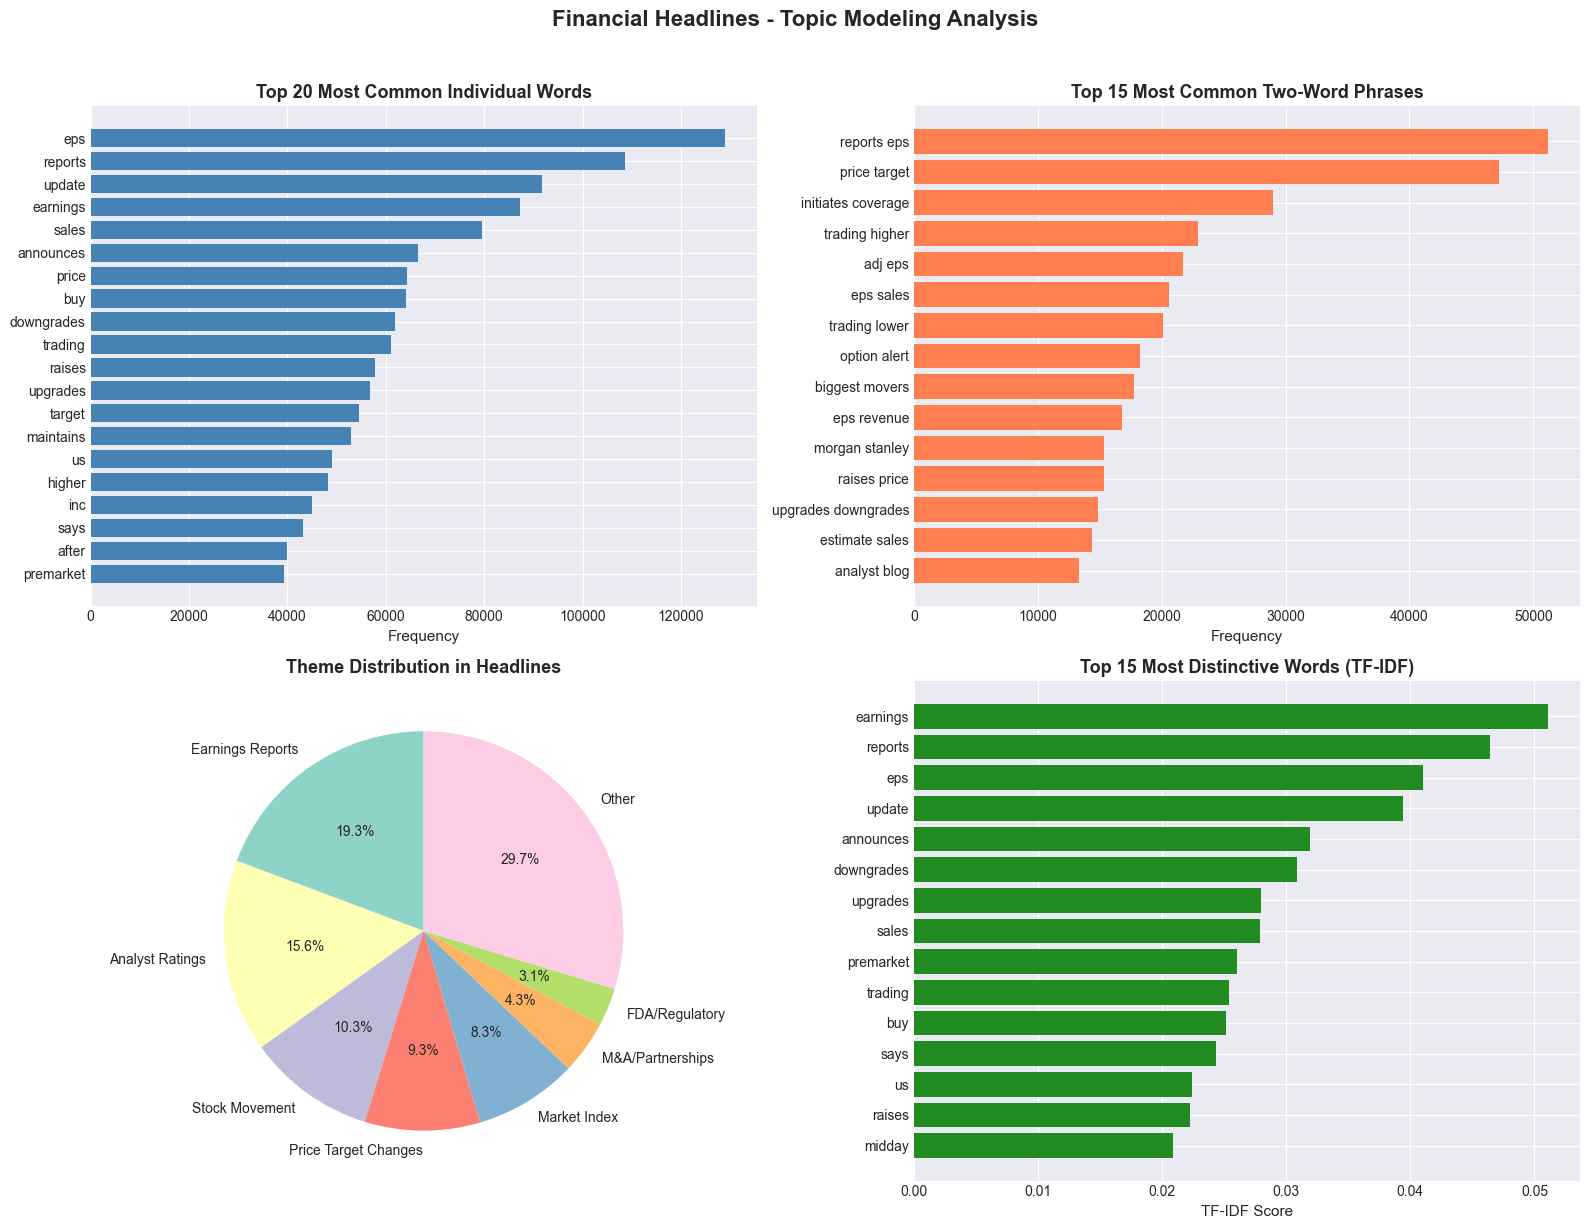

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 6a. Top 20 unigrams bar chart
top_unigrams = dict(unigram_freq[:20])
axes[0, 0].barh(list(top_unigrams.keys()), list(top_unigrams.values()), color='steelblue')
axes[0, 0].set_xlabel('Frequency', fontsize=11)
axes[0, 0].set_title('Top 20 Most Common Individual Words', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()

# 6b. Top 15 bigrams bar chart
top_bigrams = dict(bigram_freq[:15])
axes[0, 1].barh(list(top_bigrams.keys()), list(top_bigrams.values()), color='coral')
axes[0, 1].set_xlabel('Frequency', fontsize=11)
axes[0, 1].set_title('Top 15 Most Common Two-Word Phrases', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()

# 6c. Theme distribution pie chart
theme_data = dict(theme_counts.most_common(8))
if 'Other' in theme_data:
    other_val = theme_data.pop('Other')
    theme_data['Other'] = other_val

colors = plt.cm.Set3(range(len(theme_data)))
axes[1, 0].pie(theme_data.values(), labels=theme_data.keys(), autopct='%1.1f%%',
               colors=colors, startangle=90)
axes[1, 0].set_title('Theme Distribution in Headlines', fontsize=13, fontweight='bold')

# 6d. TF-IDF top words
top_tfidf = dict(tfidf_freq[:15])
axes[1, 1].barh(list(top_tfidf.keys()), list(top_tfidf.values()), color='forestgreen')
axes[1, 1].set_xlabel('TF-IDF Score', fontsize=11)
axes[1, 1].set_title('Top 15 Most Distinctive Words (TF-IDF)', fontsize=13, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.suptitle('Financial Headlines - Topic Modeling Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Time Series Analysis of News Volume

### PREPARE TIME-BASED AGGREGATIONS

In [14]:
# Extract time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['hour'] = df['date'].dt.hour
df['date_only'] = df['date'].dt.date

# Daily publication volume
daily_volume = df.groupby('date_only').size()
daily_volume.index = pd.to_datetime(daily_volume.index)

# Hourly publication volume
hourly_volume = df.groupby('hour').size()

# Day of week volume
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_volume = df.groupby('dayofweek').size()

print(f"\n📊 Dataset Time Range: {df['date'].min()} to {df['date'].max()}")
print(f"   Total days in dataset: {daily_volume.shape[0]}")
print(f"   Total articles: {len(df):,}")
print(f"   Average articles per day: {daily_volume.mean():.1f}")
print(f"   Median articles per day: {daily_volume.median():.1f}")
print(f"   Max articles in a single day: {daily_volume.max():,}")


📊 Dataset Time Range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
   Total days in dataset: 3955
   Total articles: 1,407,328
   Average articles per day: 355.8
   Median articles per day: 407.0
   Max articles in a single day: 2,739


### Visualize publication frequency over time

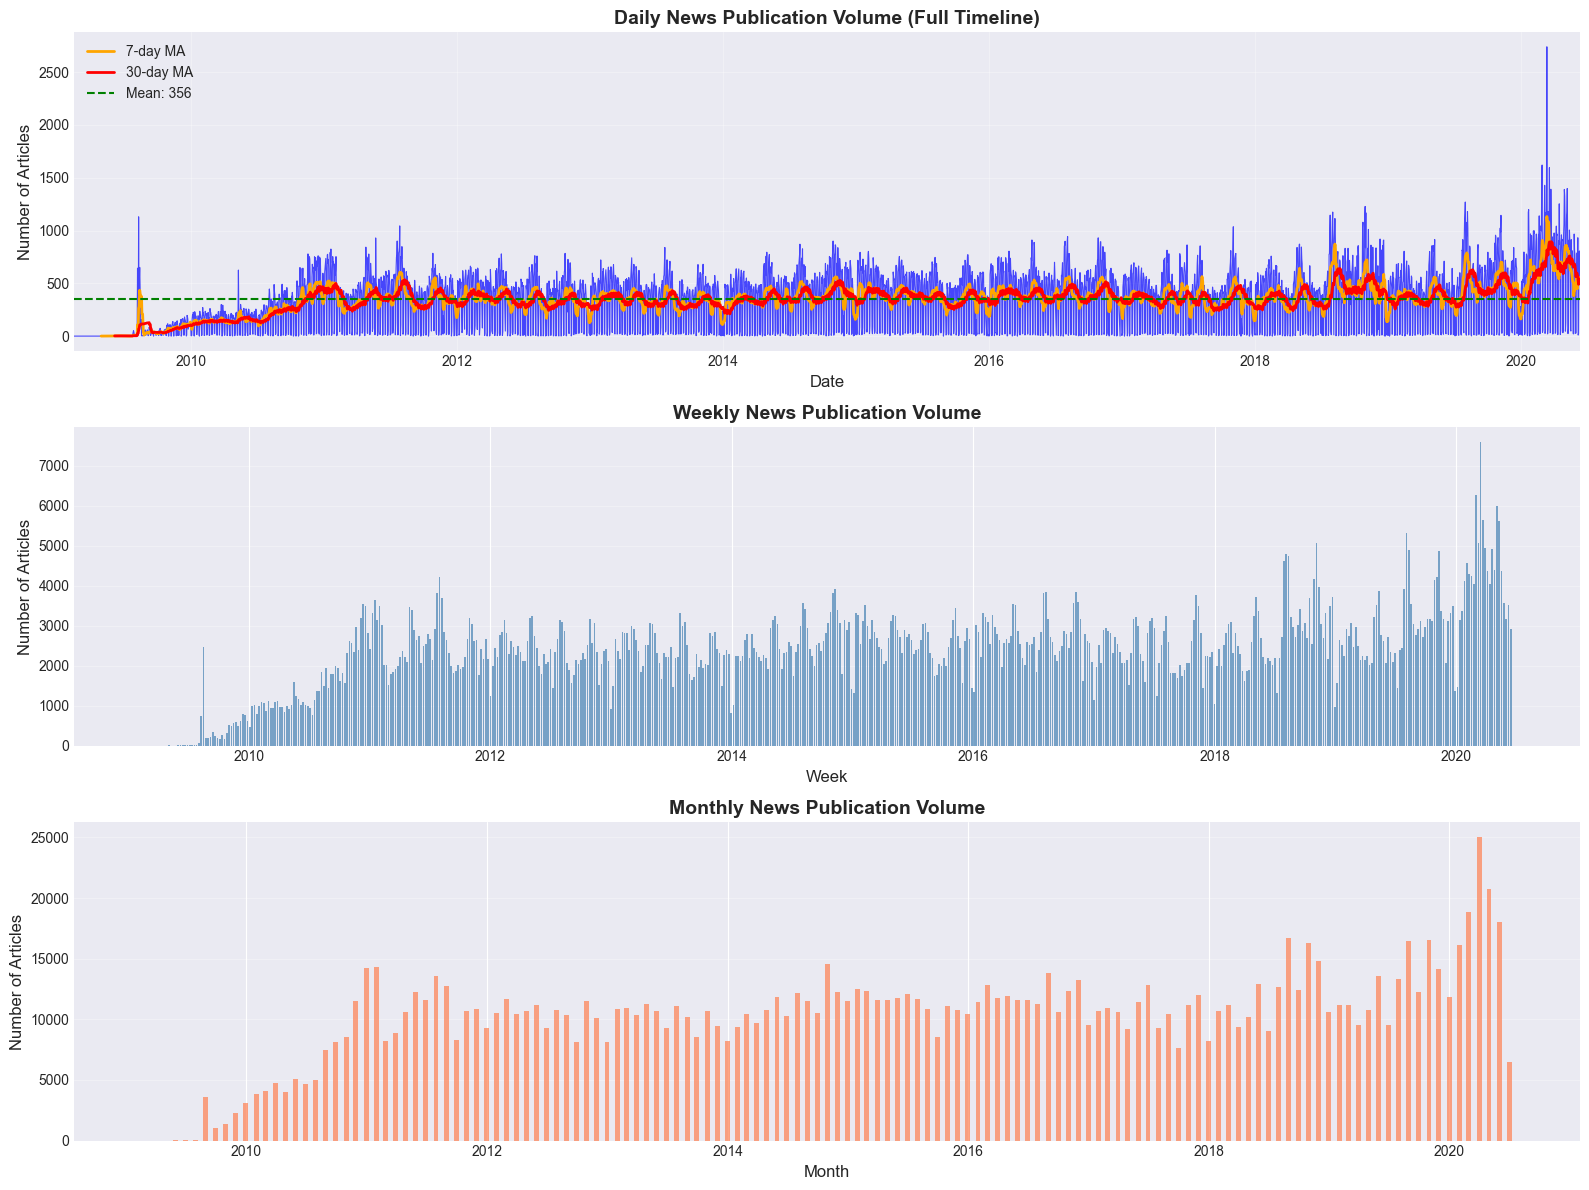

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 2a-1: Daily publication volume (full timeline)
axes[0].plot(daily_volume.index, daily_volume.values, 'b-', alpha=0.7, linewidth=0.8)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].set_title('Daily News Publication Volume (Full Timeline)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Add moving averages
rolling_7d = daily_volume.rolling(window=7, min_periods=3).mean()
rolling_30d = daily_volume.rolling(window=30, min_periods=10).mean()
axes[0].plot(rolling_7d.index, rolling_7d.values, 'orange', linewidth=2, label='7-day MA')
axes[0].plot(rolling_30d.index, rolling_30d.values, 'red', linewidth=2, label='30-day MA')
axes[0].axhline(y=daily_volume.mean(), color='green', linestyle='--', 
                label=f'Mean: {daily_volume.mean():.0f}')
axes[0].legend()
axes[0].set_xlim([daily_volume.index.min(), daily_volume.index.max()])

# 2a-2: Weekly aggregated volume
weekly_volume = daily_volume.resample('W').sum()
axes[1].bar(weekly_volume.index, weekly_volume.values, width=5, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Week', fontsize=12)
axes[1].set_ylabel('Number of Articles', fontsize=12)
axes[1].set_title('Weekly News Publication Volume', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# 2a-3: Monthly aggregated volume
monthly_volume = daily_volume.resample('M').sum()
axes[2].bar(monthly_volume.index, monthly_volume.values, width=15, color='coral', alpha=0.7)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Number of Articles', fontsize=12)
axes[2].set_title('Monthly News Publication Volume', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Identify spikes and relate market events

In [17]:
print("VOLUME SPIKE DETECTION")

# Detect spikes using multiple methods
# Method 1: Mean + 2 Standard Deviations
threshold_2sigma = daily_volume.mean() + 2 * daily_volume.std()
spikes_2sigma = daily_volume[daily_volume > threshold_2sigma]

# Method 2: Mean + 3 Standard Deviations (extreme spikes)
threshold_3sigma = daily_volume.mean() + 3 * daily_volume.std()
spikes_3sigma = daily_volume[daily_volume > threshold_3sigma]

# Method 3: Percentile-based (top 1% of days)
threshold_percentile = daily_volume.quantile(0.99)
spikes_percentile = daily_volume[daily_volume > threshold_percentile]

print(f"\n📊 Spike Detection Statistics:")
print(f"   Mean daily volume: {daily_volume.mean():.1f}")
print(f"   Standard deviation: {daily_volume.std():.1f}")
print(f"   2-sigma threshold: {threshold_2sigma:.1f}")
print(f"   3-sigma threshold: {threshold_3sigma:.1f}")
print(f"   99th percentile threshold: {threshold_percentile:.1f}")

print(f"\n📈 Detected Spikes:")
print(f"   Days above 2-sigma: {len(spikes_2sigma)} ({len(spikes_2sigma)/len(daily_volume)*100:.2f}% of days)")
print(f"   Days above 3-sigma: {len(spikes_3sigma)} ({len(spikes_3sigma)/len(daily_volume)*100:.2f}% of days)")
print(f"   Days in top 1%: {len(spikes_percentile)}")

# Top 10 highest volume days
print(f"\n🔝 TOP 10 HIGHEST NEWS VOLUME DAYS:")
for i, (date, volume) in enumerate(daily_volume.nlargest(10).items(), 1):
    # Get day of week
    dow = date.strftime('%A')
    print(f"   {i:2d}. {date} ({dow:9s}): {volume:>6,} articles")

# Identify potential market events (researched from the internet)
# Common market events: Fed meetings, earnings seasons, major economic reports, crashes
significant_dates = {
    '2020-03-12': 'S&P 500 fell 9.5%, triggered circuit breaker within minutes of opening ',
    '2020-02-28': 'S&P 500 confirmed fastest correction in history (12% drop in just 6 days)',
    '2020-03-19': 'Jobless claims surged to 281,000 (highest since Sept 2017) + stimulus debate ',
    '2020-02-27': 'Dow dropped 1,190 points (4.4%), worst week since 2008 financial crisis',
    '2020-03-06': 'OPEC+ talks collapse - Russia rejects oil production cuts',
    '2020-05-07': '33.5 million jobless claims + Moderna vaccine optimism',
    '2020-03-23': 'Market bottom - Dow closed at ~18,600 (down 33% from Feb peak) ',
    '2020-04-29': 'Gilead remdesivir positive trial results - FTSE rallied 2.8%',
    '2020-03-11': 'WHO declares pandemic + Trump travel ban announced',
    '2020-04-30': 'Another 3.84M jobless claims (30M+ total in 6 weeks)'
}

# Match spikes with known events
print(f"\n📰 POTENTIAL MARKET EVENTS CORRELATED WITH VOLUME SPIKES:")
for date, volume in spikes_3sigma.nlargest(10).items():
    date_str = date.strftime('%Y-%m-%d')
    event = significant_dates.get(date_str, 'Unknown - investigate further')
    print(f"   {date_str}: {volume:>6,} articles → {event}")

VOLUME SPIKE DETECTION

📊 Spike Detection Statistics:
   Mean daily volume: 355.8
   Standard deviation: 281.5
   2-sigma threshold: 918.9
   3-sigma threshold: 1200.4
   99th percentile threshold: 1044.5

📈 Detected Spikes:
   Days above 2-sigma: 85 (2.15% of days)
   Days above 3-sigma: 13 (0.33% of days)
   Days in top 1%: 40

🔝 TOP 10 HIGHEST NEWS VOLUME DAYS:
    1. 2020-03-12 00:00:00 (Thursday ):  2,739 articles
    2. 2020-02-28 00:00:00 (Friday   ):  1,620 articles
    3. 2020-03-19 00:00:00 (Thursday ):  1,595 articles
    4. 2020-02-27 00:00:00 (Thursday ):  1,567 articles
    5. 2020-03-06 00:00:00 (Friday   ):  1,428 articles
    6. 2020-05-07 00:00:00 (Thursday ):  1,398 articles
    7. 2020-03-23 00:00:00 (Monday   ):  1,391 articles
    8. 2020-04-29 00:00:00 (Wednesday):  1,389 articles
    9. 2020-03-11 00:00:00 (Wednesday):  1,384 articles
   10. 2020-04-30 00:00:00 (Thursday ):  1,327 articles

📰 POTENTIAL MARKET EVENTS CORRELATED WITH VOLUME SPIKES:
   2020-03-12: 

### Visualize spikes on timeline

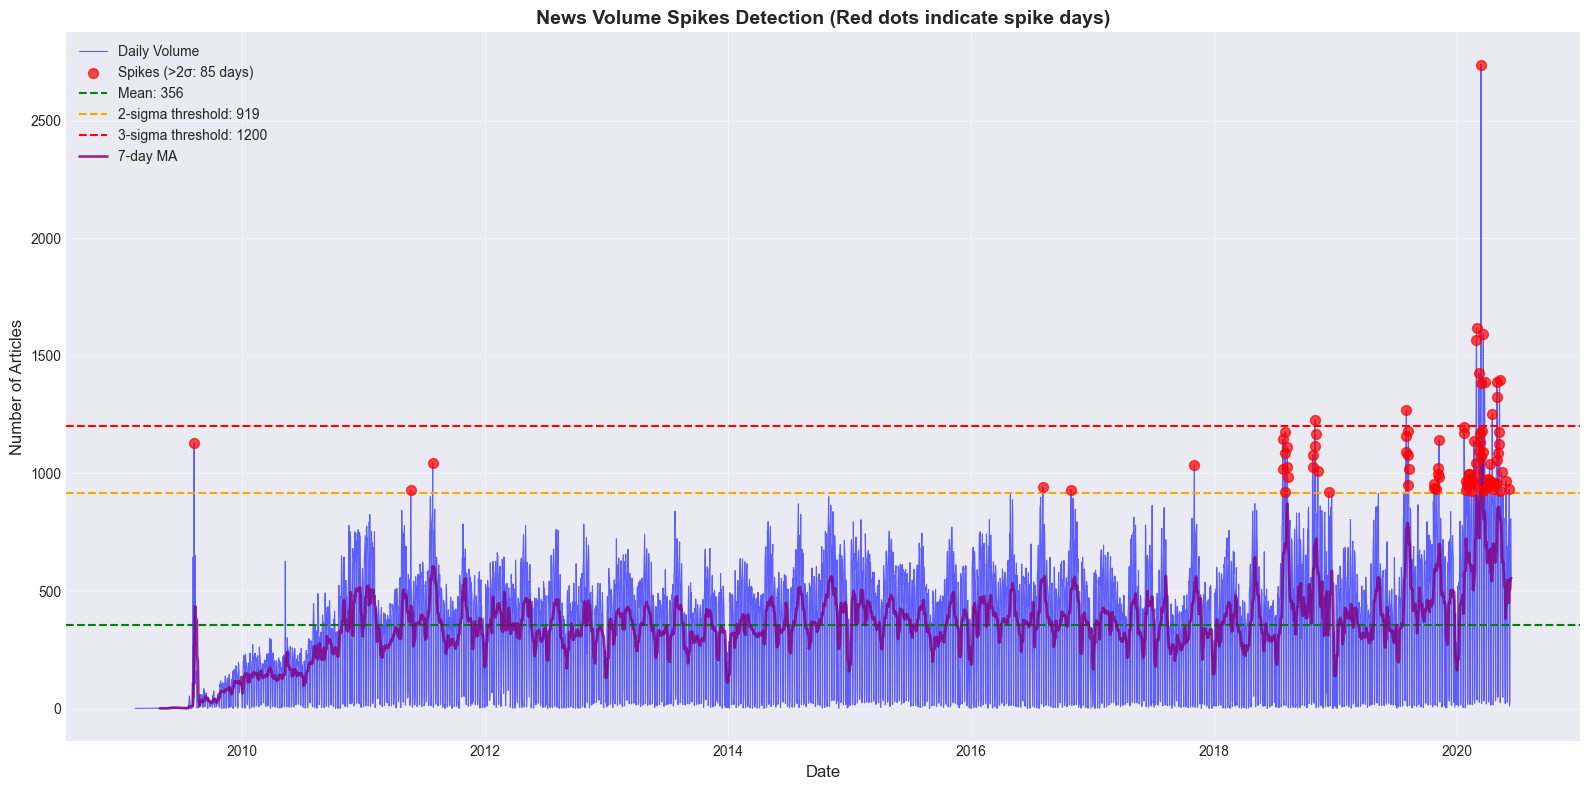

In [18]:
fig, ax = plt.subplots(figsize=(16, 8))

# Plot daily volume
ax.plot(daily_volume.index, daily_volume.values, 'b-', alpha=0.6, linewidth=0.8, label='Daily Volume')

# Highlight spikes
ax.scatter(spikes_2sigma.index, spikes_2sigma.values, color='red', s=50, 
           alpha=0.7, label=f'Spikes (>2σ: {len(spikes_2sigma)} days)', zorder=5)

# Add reference lines
ax.axhline(y=daily_volume.mean(), color='green', linestyle='--', label=f'Mean: {daily_volume.mean():.0f}')
ax.axhline(y=threshold_2sigma, color='orange', linestyle='--', label=f'2-sigma threshold: {threshold_2sigma:.0f}')
ax.axhline(y=threshold_3sigma, color='red', linestyle='--', label=f'3-sigma threshold: {threshold_3sigma:.0f}')

# Add moving average
ax.plot(rolling_7d.index, rolling_7d.values, 'purple', linewidth=2, alpha=0.8, label='7-day MA')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('News Volume Spikes Detection (Red dots indicate spike days)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Analyze publishing times

In [19]:
print("PUBLISHING TIME ANALYSIS")

# Hourly distribution
print(f"\n📊 Hourly Publication Distribution (UTC-4):")
peak_hour = hourly_volume.idxmax()
print(f"   Peak publishing hour: {peak_hour}:00 ({hourly_volume[peak_hour]:,} articles)")
print(f"   Quietest hour: {hourly_volume.idxmin()}:00 ({hourly_volume[hourly_volume.idxmin()]:,} articles)")

# Pre-market, market, after-hours breakdown
# Market hours: 9:30 AM - 4:00 PM ET (9.5 to 16 in 24h format)
pre_market = hourly_volume[hourly_volume.index < 9.5].sum() if 9.5 in hourly_volume.index else hourly_volume[hourly_volume.index <= 9].sum()
market_hours = hourly_volume[(hourly_volume.index >= 9.5) & (hourly_volume.index < 16)].sum()
after_hours = hourly_volume[hourly_volume.index >= 16].sum()

# Alternatively, if you want exact integer hours:
if 9 in hourly_volume.index and 10 in hourly_volume.index:
    pre_market = hourly_volume[hourly_volume.index <= 9].sum()
    market_hours = hourly_volume[(hourly_volume.index >= 9) & (hourly_volume.index <= 16)].sum()
    after_hours = hourly_volume[hourly_volume.index > 16].sum()

pre_pct = (pre_market / len(df)) * 100
market_pct = (market_hours / len(df)) * 100
after_pct = (after_hours / len(df)) * 100

print(f"\n📊 Time Block Distribution:")
print(f"   Pre-market (before 9:30): {pre_market:>8,} articles ({pre_pct:.1f}%)")
print(f"   Market hours (9:30-16:00): {market_hours:>8,} articles ({market_pct:.1f}%)")
print(f"   After-hours (after 16:00): {after_hours:>8,} articles ({after_pct:.1f}%)")

# Day of week analysis
print(f"\n📊 Publication Volume by Day of Week:")
for i, (dow, vol) in enumerate(dow_volume.items()):
    pct = (vol / len(df)) * 100
    bar = '█' * int(vol / dow_volume.max() * 30)
    print(f"   {dow_names[i]:10s}: {vol:>8,} ({pct:5.1f}%) {bar}")

# Weekend vs weekday
weekday_volume = dow_volume[0:5].sum()
weekend_volume = dow_volume[5:7].sum()
print(f"\n📊 Weekday vs Weekend:")
print(f"   Weekdays (Mon-Fri): {weekday_volume:>8,} articles ({weekday_volume/len(df)*100:.1f}%)")
print(f"   Weekend (Sat-Sun):  {weekend_volume:>8,} articles ({weekend_volume/len(df)*100:.1f}%)")

PUBLISHING TIME ANALYSIS

📊 Hourly Publication Distribution (UTC-4):
   Peak publishing hour: 0:00 (1,351,472 articles)
   Quietest hour: 5:00 (14 articles)

📊 Time Block Distribution:
   Pre-market (before 9:30): 1,355,158 articles (96.3%)
   Market hours (9:30-16:00):   39,932 articles (2.8%)
   After-hours (after 16:00):   14,067 articles (1.0%)

📊 Publication Volume by Day of Week:
   Monday    :  265,139 ( 18.8%) ██████████████████████████
   Tuesday   :  296,505 ( 21.1%) █████████████████████████████
   Wednesday :  300,922 ( 21.4%) █████████████████████████████
   Thursday  :  302,619 ( 21.5%) ██████████████████████████████
   Friday    :  217,918 ( 15.5%) █████████████████████
   Saturday  :    7,759 (  0.6%) 
   Sunday    :   16,466 (  1.2%) █

📊 Weekday vs Weekend:
   Weekdays (Mon-Fri): 1,383,103 articles (98.3%)
   Weekend (Sat-Sun):    24,225 articles (1.7%)


## 4. Publisher Analysis

### IDENTIFY PUBLISHER TYPES (Email vs Regular names)

In [20]:
def is_email(text):
    """Check if publisher name looks like an email address"""
    if pd.isna(text):
        return False
    email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
    return bool(re.match(email_pattern, str(text).lower()))

def extract_domain(email):
    """Extract domain from email address"""
    if pd.isna(email) or not is_email(email):
        return None
    return str(email).split('@')[-1].lower()

# Classify publishers
df['is_email'] = df['publisher'].apply(is_email)
df['domain'] = df['publisher'].apply(extract_domain)

email_publishers = df[df['is_email']]['publisher'].nunique()
regular_publishers = df[~df['is_email']]['publisher'].nunique()

print(f"\n📊 Publisher Classification:")
print(f"   Total unique publishers: {df['publisher'].nunique():,}")
print(f"   Email-based publishers: {email_publishers:,} ({email_publishers/df['publisher'].nunique()*100:.1f}%)")
print(f"   Regular name publishers: {regular_publishers:,} ({regular_publishers/df['publisher'].nunique()*100:.1f}%)")


📊 Publisher Classification:
   Total unique publishers: 1,034
   Email-based publishers: 18 (1.7%)
   Regular name publishers: 1,016 (98.3%)


### MOST ACTIVE PUBLISHERS

In [21]:
print("MOST ACTIVE PUBLISHERS")

publisher_counts = df['publisher'].value_counts()
publisher_pct = (publisher_counts / len(df)) * 100

print(f"\n📊 TOP 20 MOST ACTIVE PUBLISHERS:")
print("-" * 70)
for i, (publisher, count) in enumerate(publisher_counts.head(20).items(), 1):
    pct = (count / len(df)) * 100
    email_tag = " [EMAIL]" if is_email(publisher) else ""
    print(f"   {i:2d}. {str(publisher)[:45]:<45} {count:>8,} ({pct:5.2f}%){email_tag}")

# Concentration metrics
top1_pct = (publisher_counts.iloc[0] / len(df)) * 100
top3_pct = (publisher_counts.iloc[:3].sum() / len(df)) * 100
top5_pct = (publisher_counts.iloc[:5].sum() / len(df)) * 100
top10_pct = (publisher_counts.iloc[:10].sum() / len(df)) * 100

print(f"\n📊 Publisher Concentration:")
print(f"   Top 1 publisher: {top1_pct:.1f}% of all articles")
print(f"   Top 3 publishers: {top3_pct:.1f}% of all articles")
print(f"   Top 5 publishers: {top5_pct:.1f}% of all articles")
print(f"   Top 10 publishers: {top10_pct:.1f}% of all articles")


MOST ACTIVE PUBLISHERS

📊 TOP 20 MOST ACTIVE PUBLISHERS:
----------------------------------------------------------------------
    1. Paul Quintaro                                  228,373 (16.23%)
    2. Lisa Levin                                     186,979 (13.29%)
    3. Benzinga Newsdesk                              150,484 (10.69%)
    4. Charles Gross                                   96,732 ( 6.87%)
    5. Monica Gerson                                   82,380 ( 5.85%)
    6. Eddie Staley                                    57,254 ( 4.07%)
    7. Hal Lindon                                      49,047 ( 3.49%)
    8. ETF Professor                                   28,489 ( 2.02%)
    9. Juan Lopez                                      28,438 ( 2.02%)
   10. Benzinga Staff                                  28,114 ( 2.00%)
   11. Vick Meyer                                      24,826 ( 1.76%)
   12. webmaster                                       20,313 ( 1.44%)
   13. Benzinga_News

### ORGANIZATIONAL DOMAIN ANALYSIS (For email publishers)

In [22]:
print("ORGANIZATIONAL DOMAIN ANALYSIS")

if df['is_email'].any():
    # Count articles by domain
    domain_counts = df[df['is_email']]['domain'].value_counts()
    
    print(f"\n📊 TOP 20 MOST ACTIVE DOMAINS (from email publishers):")
    for i, (domain, count) in enumerate(domain_counts.head(20).items(), 1):
        pct = (count / len(df[df['is_email']])) * 100
        print(f"   {i:2d}. {domain:<40} {count:>6,} ({pct:5.1f}% of emails)")
    
    # Identify organizational types
    org_types = {
        'News/Media': ['benzinga', 'bloomberg', 'reuters', 'wsj', 'cnbc', 'ft.com', 'marketwatch', 'seekingalpha'],
        'Financial Institutions': ['goldman', 'morgan', 'jpmorgan', 'citi', 'bankofamerica', 'wellsfargo', 'ubs', 'credit'],
        'Research Firms': ['argus', 'zacks', 'morningstar', 'fool', 'street', 'tips'],
        'Individual/Private': ['gmail', 'yahoo', 'outlook', 'hotmail', 'icloud', 'protonmail', 'aol']
    }
    
    print(f"\n📊 DOMAIN TYPE BREAKDOWN:")
    for org_type, keywords in org_types.items():
        count = 0
        for domain in domain_counts.index:
            if any(keyword in domain for keyword in keywords):
                count += domain_counts[domain]
        if count > 0:
            pct = (count / len(df[df['is_email']])) * 100
            print(f"   {org_type:<25}: {count:>8,} ({pct:5.1f}%)")
    
    # Most prolific individual contributors (gmail/yahoo/etc)
    personal_domains = ['gmail.com', 'yahoo.com', 'outlook.com', 'hotmail.com', 'icloud.com', 'protonmail.com']
    personal_emails = df[df['domain'].isin(personal_domains)]
    
    if len(personal_emails) > 0:
        print(f"\n📊 TOP INDIVIDUAL CONTRIBUTORS (personal email domains):")
        personal_counts = personal_emails['publisher'].value_counts()
        for i, (email, count) in enumerate(personal_counts.head(15).items(), 1):
            print(f"   {i:2d}. {email:<40} {count:>6,} articles")
else:
    print("\n   No email-based publishers found in dataset.")

ORGANIZATIONAL DOMAIN ANALYSIS

📊 TOP 20 MOST ACTIVE DOMAINS (from email publishers):
    1. benzinga.com                              7,937 ( 98.1% of emails)
    2. gmail.com                                   139 (  1.7% of emails)
    3. andyswan.com                                  5 (  0.1% of emails)
    4. investdiva.com                                2 (  0.0% of emails)
    5. tothetick.com                                 2 (  0.0% of emails)
    6. eosdetroit.io                                 1 (  0.0% of emails)
    7. forextraininggroup.com                        1 (  0.0% of emails)
    8. stockmetrix.net                               1 (  0.0% of emails)

📊 DOMAIN TYPE BREAKDOWN:
   News/Media               :    7,937 ( 98.1%)
   Individual/Private       :      139 (  1.7%)

📊 TOP INDIVIDUAL CONTRIBUTORS (personal email domains):
    1. vivek.proactive@gmail.com                   120 articles
    2. richa28dhand@gmail.com                       17 articles
    3. jennifer

### VISUALIZATIONS

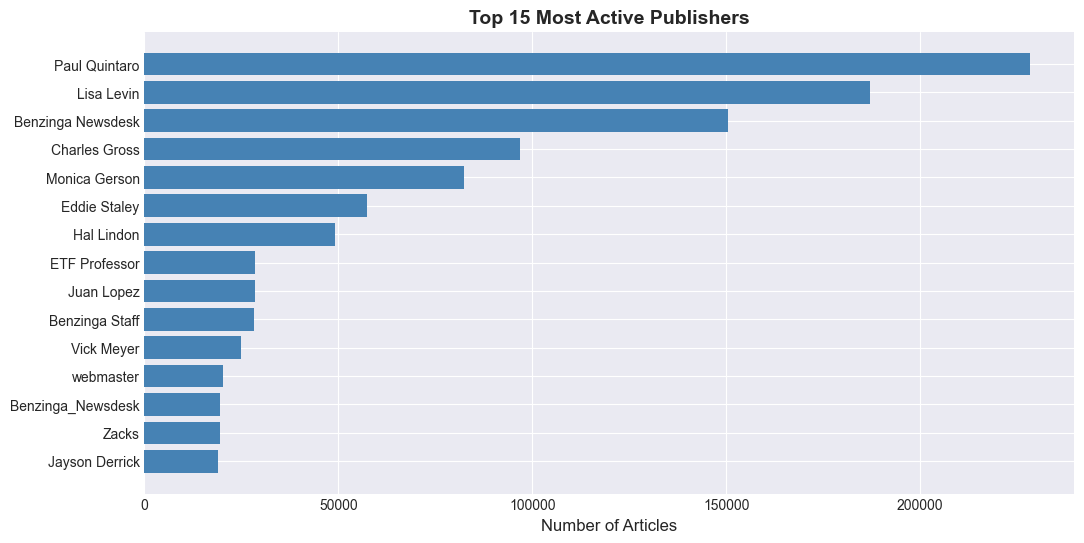

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

# Top 15 publishers bar chart
top_15_publishers = publisher_counts.head(15)
publisher_labels = [str(p)[:25] + ('...' if len(str(p)) > 25 else '') for p in top_15_publishers.index]
bars = ax.barh(range(len(top_15_publishers)), top_15_publishers.values, color='steelblue')
ax.set_yticks(range(len(top_15_publishers)))
ax.set_yticklabels(publisher_labels)
ax.set_xlabel('Number of Articles', fontsize=12)
ax.set_title('Top 15 Most Active Publishers', fontsize=14, fontweight='bold')
ax.invert_yaxis()